In [4]:
import uuid
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# PSEUDONIMIZACJA
# -----------------------------------------------------------------------------

def add_anon_id(df):
    """Nadaje każdemu rekordowi anonimowy identyfikator (pierwsze 8 znaków UUID)."""
    df = df.copy()
    df['anon_ID'] = [str(uuid.uuid4())[:8] for _ in range(len(df))]
    return df

# -----------------------------------------------------------------------------
# GENERALIZACJA — WIEK
# -----------------------------------------------------------------------------

def generalize_age(age):
    """Zamienia dokładny wiek na przedział dekadowy, np. 34 -> '30-39'."""
    if pd.isna(age):
        return 'Unknown'
    decade = (int(age) // 10) * 10
    return f"{decade}-{decade + 9}"

# -----------------------------------------------------------------------------
# KLASY RÓWNOWAŻNOŚCI
# -----------------------------------------------------------------------------

def generate_equivalence_classes(df, quasi_identifiers):
    """
    Generuje wszystkie klasy równoważności dla zadanego zbioru danych.

    Zwraca słownik:
      klucz  -> krotka wartości quasi-identyfikatorów
      wartość -> DataFrame z rekordami tej klasy
    """
    classes = {}
    for key, group in df.groupby(quasi_identifiers, observed=True):
        classes[key] = group
    return classes

# -----------------------------------------------------------------------------
# K-ANONIMOWOŚĆ (supresja)
# -----------------------------------------------------------------------------

def apply_k_anonymity(df, quasi_identifiers, k):
    """
    Stosuje k-anonimowość przez supresję: usuwa rekordy należące do klas
    równoważności liczących mniej niż k elementów.

    Zwraca przefiltrowany DataFrame.
    """
    ec_sizes = df.groupby(quasi_identifiers, observed=True).size().reset_index(name='ec_size')
    df_merged = pd.merge(df, ec_sizes, on=quasi_identifiers)
    df_result = df_merged[df_merged['ec_size'] >= k].copy()
    df_result = df_result.drop(columns=['ec_size'])
    return df_result

# -----------------------------------------------------------------------------
# WYDRUK WYNIKÓW
# -----------------------------------------------------------------------------

def print_section(title):
    print("\n" + "=" * 70)
    print(f"  {title}")
    print("=" * 70)

def print_eq_class_preview(eq_classes, n=3):
    """Drukuje podgląd pierwszych n klas równoważności."""
    print(f"Łącznie klas równoważności: {len(eq_classes)}")
    print(f"Podgląd {n} pierwszych klas:")
    for i, (key, group) in enumerate(eq_classes.items()):
        if i >= n:
            break
        print(f"  -> Klasa {key}: {len(group)} rekordów")

def print_k_anonymity_summary(df_before, df_after, k):
    """Drukuje podsumowanie k-anonimizacji."""
    lost = len(df_before) - len(df_after)
    print(f"Parametr k          : {k}")
    print(f"Rekordy przed       : {len(df_before)}")
    print(f"Rekordy po supresji : {len(df_after)}")
    print(f"Usunięto rekordów   : {lost} ({lost / len(df_before) * 100:.1f}%)")

def verify_k_anonymity(df, quasi_identifiers, k):
    """Weryfikuje czy zbiór spełnia k-anonimowość i drukuje wynik."""
    min_ec = df.groupby(quasi_identifiers, observed=True).size().min()
    satisfied = min_ec >= k
    print(f"Minimalna klasa równoważności: {min_ec} rekordów")
    if satisfied:
        print(f"✓  Zbiór spełnia {k}-anonimowość")
    else:
        print(f"✗  Zbiór NIE spełnia {k}-anonimowości!")
    return satisfied

# -----------------------------------------------------------------------------
# CZYSZCZENIE DANYCH
# -----------------------------------------------------------------------------

def clean_dataframe(df, int_cols=None, float_cols=None):
    """
    Usuwa braki i duplikaty, opcjonalnie wymusza typy kolumn.

    Parametry:
      int_cols   -- lista kolumn do rzutowania na int   (np. ['age'])
      float_cols -- lista kolumn do rzutowania na float (np. ['bmi'])

    Zwraca oczyszczony DataFrame.
    """
    before = len(df)
    df = df.dropna()
    print(f"Usunięto wierszy z brakującymi wartościami : {before - len(df)}")

    dupes = df.duplicated().sum()
    df = df.drop_duplicates()
    print(f"Usunięto duplikatów                        : {dupes}")
    print(f"Rekordy po czyszczeniu                     : {len(df)}")

    for col in (int_cols or []):
        df[col] = df[col].astype(int)
    for col in (float_cols or []):
        df[col] = df[col].astype(float)

    return df

# -----------------------------------------------------------------------------
# L-RÓŻNORODNOŚĆ
# -----------------------------------------------------------------------------

def compute_entropy(group, sensitive_attr):
    """Oblicza entropię rozkładu atrybutu wrażliwego w danej klasie."""
    probs = group[sensitive_attr].value_counts(normalize=True)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log(probs))

def apply_l_diversity(df, quasi_identifiers, sensitive_attr, l):
    """
    Stosuje l-różnorodność przez supresję: usuwa klasy równoważności,
    których entropia rozkładu atrybutu wrażliwego jest mniejsza niż log(l).
    """
    log_l = np.log(l)

    ec_entropy = (
        df.groupby(quasi_identifiers, observed=True)
        .apply(lambda g: compute_entropy(g, sensitive_attr), include_groups=False)
        .reset_index(name='entropy')
    )

    df_merged = pd.merge(df, ec_entropy, on=quasi_identifiers)
    df_result = df_merged[df_merged['entropy'] >= log_l].drop(columns=['entropy'])
    return df_result

def print_l_diversity_summary(df_before, df_after, l):
    """Drukuje podsumowanie l-dywersyfikacji."""
    lost = len(df_before) - len(df_after)
    print(f"Parametr l             : {l}")
    print(f"Rekordy przed          : {len(df_before)}")
    print(f"Rekordy po supresji    : {len(df_after)}")
    print(f"Usunięto rekordów      : {lost} ({lost / len(df_before) * 100:.1f}%)")

def verify_l_diversity(df, quasi_identifiers, sensitive_attr, l):
    """Weryfikuje czy zbiór spełnia l-różnorodność i drukuje wynik."""
    log_l = np.log(l)
    entropies = df.groupby(quasi_identifiers, observed=True).apply(
        lambda g: compute_entropy(g, sensitive_attr), include_groups=False
    )
    min_entropy = entropies.min()
    satisfied = min_entropy >= log_l
    print(f"Minimalna entropia w klasie : {min_entropy:.4f}  (log({l}) = {log_l:.4f})")
    if satisfied:
        print(f"✓  Zbiór spełnia {l}-różnorodność")
    else:
        print(f"✗  Zbiór NIE spełnia {l}-różnorodności!")
    return satisfied

def print_entropy_preview(df, quasi_identifiers, sensitive_attr, n=5):
    """Drukuje entropię dla n najmniejszych klas — przydatne do debugowania."""
    entropies = (
        df.groupby(quasi_identifiers, observed=True)
        .apply(lambda g: pd.Series({
            'entropy': compute_entropy(g, sensitive_attr),
            'size': len(g),
            'unique_values': g[sensitive_attr].nunique(),
        }), include_groups=False)
        .reset_index()
        .sort_values('entropy')
    )
    print(f"Klasy z najniższą entropią (podgląd {n}):")
    print(entropies.head(n).to_string(index=False))

# -----------------------------------------------------------------------------
# ADAPTACYJNE WYSZUKIWANIE OPTYMALNYCH PARAMETRÓW
# -----------------------------------------------------------------------------

def generalize_numeric_qcut(series, n_bins):
    """
    Generalizuje kolumnę numeryczną do n_bins kwantylowych przedziałów.
    """
    try:
        labels = [f'cat_{i + 1}' for i in range(n_bins)]
        return pd.qcut(series, q=n_bins, labels=labels, duplicates='drop')
    except ValueError:
        return None

def adaptive_search(df, qi_categorical, qi_numerical, sensitive_attr,
                    k_values, l_values, n_bins_options, top_n=15):
    """
    Przeszukuje przestrzeń parametrów (k, l, podziały kolumn numerycznych)
    szukając kombinacji która maksymalizuje liczbę zachowanych rekordów.
    """
    total = len(df)
    num_cols = list(qi_numerical.keys())
    results = []

    bin_combinations = list(itertools.product(n_bins_options, repeat=len(num_cols)))
    total_combinations = len(k_values) * len(l_values) * len(bin_combinations)

    print(f"Przestrzeń poszukiwań:")
    print(f"  k: {k_values}")
    print(f"  l: {l_values}")
    print(f"  kubełki: {n_bins_options} dla każdej z {len(num_cols)} kolumn numerycznych")
    print(f"  łącznie kombinacji: {total_combinations}")
    print(f"\nPrzeszukiwanie...", end='', flush=True)

    checked = 0
    for k in k_values:
        for l in l_values:
            if l > k:
                continue

            for bin_combo in bin_combinations:
                checked += 1
                if checked % 20 == 0:
                    print('.', end='', flush=True)

                generalized_cols = {}
                valid = True
                for col, n_bins in zip(num_cols, bin_combo):
                    gen = generalize_numeric_qcut(qi_numerical[col], n_bins)
                    if gen is None:
                        valid = False
                        break
                    generalized_cols[col] = gen

                if not valid:
                    continue

                cat_col_names = [f'{col}_g{n}' for col, n in zip(num_cols, bin_combo)]
                df_work = df[['anon_ID'] + qi_categorical + [sensitive_attr]].copy()
                for col, cat_name, gen_series in zip(num_cols, cat_col_names, generalized_cols.values()):
                    df_work[cat_name] = gen_series.values

                Q = qi_categorical + cat_col_names

                df_k = apply_k_anonymity(df_work, Q, k)
                if len(df_k) == 0:
                    continue

                df_l = apply_l_diversity(df_k, Q, sensitive_attr, l)
                retained = len(df_l)

                row = {
                    'k': k,
                    'l': l,
                    'retained': retained,
                    'pct_retained': round(retained / total * 100, 1),
                    'removed': total - retained,
                }
                for col, n in zip(num_cols, bin_combo):
                    row[f'{col}_bins'] = n

                results.append(row)

    print(f'\nSprawdzono {checked} kombinacji.\n')

    if not results:
        print("Brak wyników — żadna kombinacja nie spełniła warunków.")
        return pd.DataFrame()

    df_results = (
        pd.DataFrame(results)
        .sort_values(['retained', 'k', 'l'], ascending=[False, False, False])
        .reset_index(drop=True)
    )

    return df_results

def print_adaptive_results(df_results, top_n=15):
    if df_results.empty:
        return
    print(f"Top {min(top_n, len(df_results))} kombinacji (posortowane wg zachowanych rekordów):")
    print(df_results.head(top_n).to_string(index=False))
    best = df_results.iloc[0]
    print(f"\n{'=' * 50}")
    print(f"OPTIMUM:")
    print(f"  k               = {best['k']}")
    print(f"  l               = {best['l']}")
    for col in df_results.columns:
        if col.endswith('_bins'):
            print(f"  {col:<15} = {int(best[col])}")
    print(f"  Zachowane rekordy: {int(best['retained'])} / {int(best['retained'] + best['removed'])} ({best['pct_retained']}%)")
    print(f"{'=' * 50}")


  1. WCZYTANIE I PRZYGOTOWANIE DANYCH (Medical Cost)
Początkowa liczba rekordów: 1338
Usunięto wierszy z brakującymi wartościami : 0
Usunięto duplikatów                        : 1
Rekordy po czyszczeniu                     : 1337

  2. PSEUDONIMIZACJA
Quasi-identyfikatory kategoryczne : ['sex', 'region']
Quasi-identyfikatory numeryczne   : ['age', 'bmi']
Atrybut wrażliwy                  : charges_cat

  3. ADAPTACYJNE WYSZUKIWANIE
Przestrzeń poszukiwań:
  k: [2, 3, 5, 10]
  l: [2, 3, 4]
  kubełki: [2, 3, 4, 5, 6] dla każdej z 2 kolumn numerycznych
  łącznie kombinacji: 300

Przeszukiwanie..............
Sprawdzono 225 kombinacji.

Top 15 kombinacji (posortowane wg zachowanych rekordów):
 k  l  retained  pct_retained  removed  age_bins  bmi_bins
10  2      1337         100.0        0         2         2
10  2      1337         100.0        0         2         3
 5  2      1337         100.0        0         2         2
 5  2      1337         100.0        0         2         3
 3  2   

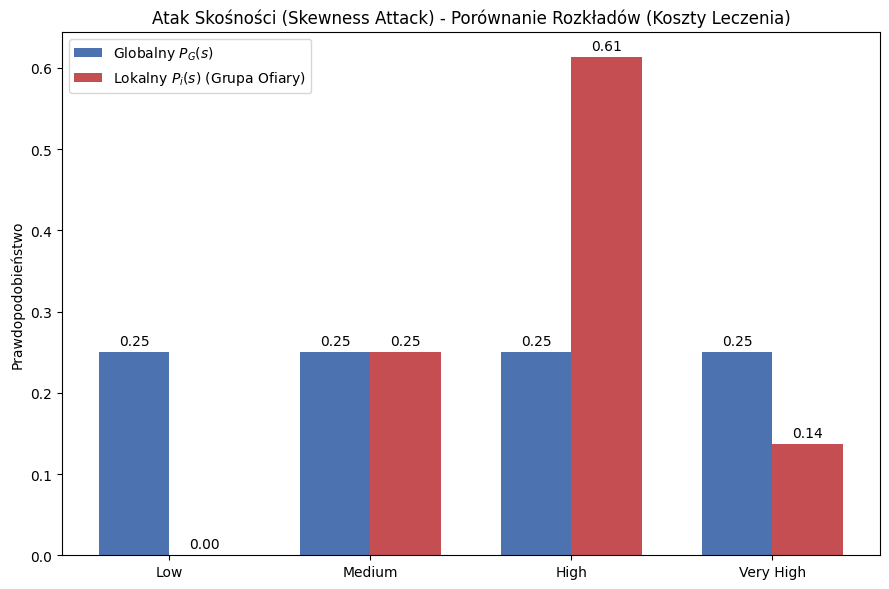

In [ ]:
print_section("1. WCZYTANIE I PRZYGOTOWANIE DANYCH (Medical Cost)")


# Wczytanie z pliku csv zamiast repozytorium UCI
DATASET_PATH = 'insurance.csv'
try:
    df = pd.read_csv(DATASET_PATH)
except FileNotFoundError:
    print(f"Błąd: Nie znaleziono pliku '{DATASET_PATH}'. Pamiętaj o umieszczeniu go w katalogu roboczym.")
    exit(1)


print(f"Początkowa liczba rekordów: {len(df)}")
df = clean_dataframe(df, int_cols=['age'], float_cols=['bmi'])


# =============================================================================
# Zmienna 'charges' jest zmienną ciągłą (float). Klasyczna implementacja 
# l-różnorodności (oparta na unikalnych wartościach) oraz Atak Skośności
# nie sprawdzają się na wartościach ciągłych (prawie każdy pacjent ma inne opłaty).
# Dlatego przed analizą kategoryzujemy 'charges' na 4 grupy (Kwartyle).
# =============================================================================
df['charges_cat'] = pd.qcut(df['charges'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])


print_section("2. PSEUDONIMIZACJA")


df = add_anon_id(df)


# Definicja ról atrybutów dla zbioru Medical
SENSITIVE       = 'charges_cat'
QI_CATEGORICAL  = ['sex', 'region']


# Kolumny numeryczne do adaptacyjnej generalizacji
QI_NUMERICAL    = {
    'age': df['age'],
    'bmi': df['bmi']
}


print(f"Quasi-identyfikatory kategoryczne : {QI_CATEGORICAL}")
print(f"Quasi-identyfikatory numeryczne   : {list(QI_NUMERICAL.keys())}")
print(f"Atrybut wrażliwy                  : {SENSITIVE}")


print_section("3. ADAPTACYJNE WYSZUKIWANIE")


# Przestrzeń poszukiwań dostosowana dla małego zbioru Medical Cost
K_VALUES      = [2, 3, 5, 10]
L_VALUES      = [2, 3, 4]
N_BINS_OPTIONS = [2, 3, 4, 5, 6]


df_results = adaptive_search(
    df             = df,
    qi_categorical = QI_CATEGORICAL,
    qi_numerical   = QI_NUMERICAL,
    sensitive_attr = SENSITIVE,
    k_values       = K_VALUES,
    l_values       = L_VALUES,
    n_bins_options = N_BINS_OPTIONS,
    top_n          = 15,
)


print_adaptive_results(df_results, top_n=15)


print_section("4. WYNIK DLA OPTYMALNEJ KOMBINACJI")


if not df_results.empty:
    best = df_results.iloc[0]
    k_best     = int(best['k'])
    l_best     = int(best['l'])
    age_bins   = int(best['age_bins'])
    bmi_bins   = int(best['bmi_bins'])


    print(f"Parametry: k={k_best}, l={l_best}, age_bins={age_bins}, bmi_bins={bmi_bins}")


    # Odtwórz generalizację z optymalnymi parametrami
    df['age_gen'] = generalize_numeric_qcut(df['age'], age_bins)
    df['bmi_gen'] = generalize_numeric_qcut(df['bmi'], bmi_bins)
    
    Q_best = QI_CATEGORICAL + ['age_gen', 'bmi_gen']


    df_work = df[['anon_ID'] + Q_best + [SENSITIVE]].copy()


    df_k = apply_k_anonymity(df_work, Q_best, k=k_best)
    df_kl = apply_l_diversity(df_k, Q_best, SENSITIVE, l=l_best)


    print(f"\nRekordy przed : {len(df)}")
    print(f"Po k-anonimowości ({k_best}) : {len(df_k)}")
    print(f"Po l-różnorodności ({l_best}) : {len(df_kl)}")
    print()
    verify_k_anonymity(df_kl, Q_best, k_best)
    print()
    verify_l_diversity(df_kl, Q_best, SENSITIVE, l_best)
    print()
    print_entropy_preview(df_kl, Q_best, SENSITIVE, n=5)


    print("\nPrzykładowe rekordy po anonimizacji:")
    print(df_kl.head(10).to_string(index=False))
    
    print_section("5. ATAK SKOŚNOŚCI (SKEWNESS ATTACK)")


    TAU = 0.15


    # 1. Obliczenie rozkładu globalnego P_G(s)
    P_G = df_kl[SENSITIVE].value_counts(normalize=True)
    
    print("Histogram Globalny P_G(s):")
    for val, prob in P_G.items():
        print(f"  {val}: {prob:.4f}")
    print(f"\nPróg pewności (tau): {TAU}")


    # 2. Grupowanie ofiar po klasach równoważności (EC_i)
    grouped = df_kl.groupby(Q_best, observed=True)
    successful_attacks = []


    for ec_name, group in grouped:
        # Rozkład Lokalny P_i(s)
        P_i = group[SENSITIVE].value_counts(normalize=True)
        
        is_successful = False
        max_diff = 0
        skewed_value = None
        
        # Porównujemy każdą możliwą wartość atrybutu wrażliwego
        for val in P_G.index:
            p_global_val = P_G.get(val, 0)
            p_local_val = P_i.get(val, 0)
            
            diff = abs(p_local_val - p_global_val)
            
            # Sprawdzenie warunku ataku
            if diff > TAU:
                is_successful = True
                if diff > max_diff:
                    max_diff = diff
                    skewed_value = val
                    
        if is_successful:
            successful_attacks.append({
                'ec_name': ec_name,
                'size': len(group),
                'P_i': P_i,
                'max_diff': max_diff,
                'skewed_value': skewed_value
            })


    print(f"\nZnaleziono {len(successful_attacks)} klas(y) podatnych na atak skośności.")


    # 3. Jeśli atak się powiódł, pokaż najbardziej podatną grupę
    if successful_attacks:
        # Sortujemy, aby znaleźć grupę z największym odchyleniem
        successful_attacks.sort(key=lambda x: x['max_diff'], reverse=True)
        victim_group = successful_attacks[0]
        
        print("\n" + "=" * 60)
        print(" SZCZEGÓŁY UDANEGO ATAKU (Najbardziej podatna klasa)")
        print("=" * 60)
        
        print("Quasi-identyfikatory ofiary (EC_i):")
        for q, v in zip(Q_best, victim_group['ec_name']):
            print(f"  {q}: {v}")
            
        print(f"\nRozmiar grupy: {victim_group['size']} rekordów")
        
        print("\nHistogram Lokalny P_i(s):")
        for val, prob in victim_group['P_i'].items():
            print(f"  {val}: {prob:.4f}")
            
        print(f"\nMaksymalne odchylenie dla wartości '{victim_group['skewed_value']}': {victim_group['max_diff']:.4f} > {TAU} (Atak Udany!)")
        
        # 4. Generowanie wykresu (Porównanie histogramów)
        labels = P_G.index.astype(str).tolist()
        x = np.arange(len(labels))
        width = 0.35
        
        global_vals = [P_G.get(l, 0) for l in P_G.index]
        local_vals = [victim_group['P_i'].get(l, 0) for l in P_G.index]
        
        fig, ax = plt.subplots(figsize=(9, 6))
        rects1 = ax.bar(x - width/2, global_vals, width, label='Globalny $P_G(s)$', color='#4C72B0')
        rects2 = ax.bar(x + width/2, local_vals, width, label='Lokalny $P_i(s)$ (Grupa Ofiary)', color='#C44E52')
        
        # Formatowanie wykresu
        ax.set_ylabel('Prawdopodobieństwo')
        ax.set_title('Atak Skośności (Skewness Attack) - Porównanie Rozkładów (Koszty Leczenia)')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.legend()
        
        # Dodanie etykiet nad słupkami dla lepszej czytelności
        for rect in rects1 + rects2:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 punkty przesunięcia pionowego
                        textcoords="offset points",
                        ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    else:
        print("\nŻadna klasa równoważności nie przekroczyła zadanego progu tau.")
        print("Zbiór jest odporny na ten wariant ataku skośności przy obecnych parametrach.")
else:
    print("Błąd: Brak wyników wyszukiwania - nie można wygenerować zanonimizowanego zbioru 'df_kl'.")